# Multi-objective Diet Optimization — main experiment notebook

This notebook runs the **end-to-end experimental pipeline** for the BAO group project: load the dataset, tune algorithm hyperparameters, run the final benchmark grid, then regenerate the tables/plots used in the report.

**Pipeline (high level)**
1. Load the food database and the subject profiles from MySQL.
2. **Hyperparameter tuning.** Run a grid for each algorithm (NSGA-II, PAES, MOPSO, P-ACO), save `experiments/tuning_results.csv`, and pick the best hyperparameters.
3. **Main grid.** Run 30 stochastic replicates per (configuration, subject). Save `experiments/all_runs.csv`.
4. **Statistics + plots.** Regenerate `summary.csv`, statistical tests (Wilcoxon+Shaffer, Friedman Aligned Ranks), and the figures referenced by `report.tex`.

**Before you run**
- Ensure your database connection is configured via environment variables (loaded from a local `.env`).
- This notebook always runs the full experiment with 30 replicates for report-quality results.
- Full end-to-end runs take **~30–60+ minutes** on a typical laptop (depends on `n_jobs`, CPU, and DB speed).
- The experiment will regenerate all results from scratch (no caching).

**Outputs**
Everything written under `experiments/` is intended to be reproducible artefacts for the report (CSVs + PNGs).

> **About saved cell outputs**: The inline outputs shown in this notebook come from one execution of the pipeline. Use the CSV artefacts in `experiments/` (especially `all_runs.csv` and `summary.csv`) when refreshing the tables in `report.tex`. Runtime figures are hardware-dependent and can differ across machines.

## 0. Setup

This section imports dependencies, sets up output paths, and loads `.env` variables (for the MySQL connection).
- The notebook writes all artefacts to `experiments/`.
- If you get DB connection errors later, double-check your `.env` values and that the database is reachable.

In [13]:
# Standard imports + project paths.
from __future__ import annotations
import os, sys, time, json
from pathlib import Path

PROJECT_ROOT = Path.cwd()
EXP_DIR = PROJECT_ROOT / "experiments"
EXP_DIR.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# Full experiment configuration (30 replicates, 5 tuning runs, all subjects)
N_JOBS = min(4, os.cpu_count() or 1)
TUNING_RUNS = 5
MAIN_RUNS = 30
TUNING_RESULTS_CSV = EXP_DIR / "tuning_results.csv"
TUNING_BEST_CSV = EXP_DIR / "tuning_best.csv"
ALL_RUNS_CSV = EXP_DIR / "all_runs.csv"

print('Project root:', PROJECT_ROOT)
print('Outputs dir :', EXP_DIR)
print('Config      : Full experiment (30 replicates per configuration)')

Project root: /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem
Outputs dir : /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments
Config      : Full experiment (30 replicates per configuration)


## 1. Load the food database + subject profiles

We load two things from the project dataset:
- **Foods**: the candidate items that can appear in a diet plan.
- **Subjects**: user profiles with an ID, age, and a target caloric intake.

This step should be fast. If it fails, it usually indicates a DB/config problem rather than an algorithm issue.

In [14]:
from diet_bao.experiment import load_real_dataset

foods, subjects = load_real_dataset()
print(f'Foods loaded     : {len(foods)}')
print(f'Subjects loaded  : {len(subjects)}')
for s in subjects:
    print(f'  subject {s.sujeto_id}: age={s.edad:2d}, target={s.calorias:.0f} kcal/day')


Foods loaded     : 2616
Subjects loaded  : 5
  subject 1: age=17, target=2877 kcal/day
  subject 2: age=30, target=2568 kcal/day
  subject 3: age=40, target=3103 kcal/day
  subject 4: age=55, target=1710 kcal/day
  subject 5: age=72, target=1401 kcal/day


## 2. Hyperparameter tuning

We tune each algorithm on a **small grid** (typically 8–16 combinations). Each combination is evaluated
`TUNING_RUNS` times on a representative subset of subjects, and we select the configuration with the best mean
**hypervolume** (HV).

**Metric directions**
- HV: higher is better (better Pareto front coverage / dominance, computed against a common per-subject reference point)
- IGD: lower is better (closer to a reference front)

> Tip: tuning is optional if you already have `experiments/tuning_best.csv`. You can skip to Section 3 and load it from disk there.

**Artefacts**
- `experiments/tuning_results_quick.csv` in quick mode, or `experiments/tuning_results.csv` in full mode: raw grid results across seeds and subjects.
- `experiments/tuning_best_quick.csv` in quick mode, or `experiments/tuning_best.csv` in full mode: the best configuration per algorithm (used to build the main grid).

In [15]:
from diet_bao.experiment import default_tuning_grids, run_tuning_grid, best_configurations

tuning_subject_ids = (1, 4)
tuning_subjects = [s for s in subjects if s.sujeto_id in tuning_subject_ids]
print('Tuning on subjects:', [s.sujeto_id for s in tuning_subjects])

grids = default_tuning_grids()

total_combos = 0
for g in grids:
    from diet_bao.experiment.tuning import _expand_grid
    n = len(_expand_grid(g))
    total_combos += n
    print(f'  {g.algorithm:10s}: {n} combinations')
print(f'Total: {total_combos} combos x {TUNING_RUNS} reps x {len(tuning_subjects)} subjects = {total_combos*TUNING_RUNS*len(tuning_subjects)} runs')

Tuning on subjects: [1, 4]
  NSGA-II   : 12 combinations
  PAES      : 12 combinations
  MOPSO     : 16 combinations
  P-ACO     : 16 combinations
Total: 56 combos x 5 reps x 2 subjects = 560 runs


In [16]:
tuning_csv = TUNING_RESULTS_CSV
t0 = time.perf_counter()
tuning_df = run_tuning_grid(
    grids,
    tuning_subjects,
    foods,
    n_runs=TUNING_RUNS,
    seed0=1000,
    n_jobs=N_JOBS,
)
print(f'Tuning done in {(time.perf_counter()-t0)/60:.1f} min -- {len(tuning_df)} rows.')
tuning_df.to_csv(tuning_csv, index=False)
print('Saved:', tuning_csv)

Tuning done in 18.4 min -- 560 rows.
Saved: /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/tuning_results.csv


In [17]:
best = best_configurations(tuning_df)
best.to_csv(TUNING_BEST_CSV, index=False)
print('Saved:', TUNING_BEST_CSV)

for algo, g in best.groupby('algorithm'):
    print(f'\n=== {algo} (top 3) ===')
    cols = [c for c in ('config_id','pop_size','max_generations','mutation_rate',
                        'inertia','c1','w1','w2','max_archive_size',
                        'hv_mean','igd_mean','runtime_mean') if c in g.columns]
    print(g.head(3)[cols].to_string(index=False))


Saved: /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/tuning_best.csv

=== MOPSO (top 3) ===
                      config_id  pop_size  max_generations  mutation_rate  inertia  c1  max_archive_size       hv_mean   igd_mean  runtime_mean
mopso_p30_g80_w04_c20_a80_sigma        30               80            NaN      0.4 2.0              80.0 489400.615254 566.949656      0.295045
mopso_p30_g80_w04_c20_a40_sigma        30               80            NaN      0.4 2.0              40.0 489400.615254 566.949656      0.295762
mopso_p60_g80_w04_c20_a80_sigma        60               80            NaN      0.4 2.0              80.0 469800.246107 535.952265      0.530785

=== NSGA-II (top 3) ===
          config_id  pop_size  max_generations  mutation_rate  inertia  c1  max_archive_size       hv_mean   igd_mean  runtime_mean
 nsgaii_p80_g80_m02        80               80           0.20      NaN NaN               NaN 969653.601470 264.092219      1.38

## 3. Main grid — tuned configs × all subjects × 30 replicates

This section builds the **final configuration list** using the tuned hyperparameters and then runs the full benchmark.

**What it does**
- Creates algorithm/config variants (representation + constraint handling).
- Runs every configuration on all 5 subjects with 30 replicates each.
- Writes raw run-level metrics to `experiments/all_runs.csv`.

**Hyperparameter selection logic**
- The `pick()` helper reads the rank-1 row from `experiments/tuning_best.csv` for each algorithm (highest mean HV, ties broken by lowest runtime).
- If a key is tied across archive sizes (as sometimes happens for P-ACO), the faster-runtime variant wins.
- The fallback `DEFAULT_HP` dict is only used when `tuning_best.csv` has no row for that algorithm.

**Runtime / reproducibility notes**
- The `seed0` and per-run seeds make the experiment repeatable (assuming deterministic dependencies).
- `n_jobs` controls parallel execution; set it lower if your machine becomes unresponsive.
- Runtime is measured per-run (wall-clock inside the worker), so it reflects true single-run cost independent of parallelism.

> Note: This section will regenerate `experiments/all_runs.csv` with all fresh results from scratch.

In [18]:
from diet_bao.experiment import AlgorithmConfig, BenchmarkPlan, run_all_subjects

# If you skip the tuning section, load the tuned hyperparameters from disk.
if "best" not in globals():
    best_path = TUNING_BEST_CSV
    best = pd.read_csv(best_path)
    print("Loaded:", best_path)

DEFAULT_HP = {
    "NSGA-II": {"pop_size": 80, "max_generations": 80, "mutation_rate": 0.1},
    "PAES": {"pop_size": 1, "max_generations": 800, "mutation_rate": 0.1, "max_archive_size": 80},
    "MOPSO": {"pop_size": 60, "max_generations": 80, "max_archive_size": 80, "inertia": 0.4, "c1": 1.5, "c2": 1.5, "leader_method": "sigma"},
    "P-ACO": {"pop_size": 40, "max_generations": 80, "max_archive_size": 80, "evaporation_rate": 0.1, "alpha": 1.0, "initial_pheromone": 1.0},
}

def pick(algo: str, defaults: dict | None = None) -> dict:
    out = dict(defaults or {})
    gdf = best[best["algorithm"] == algo]
    if gdf.empty:
        return out
    g = gdf.iloc[0]
    keys = [
        "pop_size",
        "max_generations",
        "mutation_rate",
        "inertia",
        "c1",
        "c2",
        "max_archive_size",
        "evaporation_rate",
        "alpha",
        "q",
        "initial_pheromone",
        "leader_method",
    ]
    out.update({k: g[k] for k in keys if k in g and pd.notna(g[k])})
    return out

def split(hp: dict, extras: list[str], pop_default: int = 50, gen_default: int = 50) -> dict:
    hp = dict(hp)
    pop = int(hp.pop("pop_size", pop_default))
    gens = int(hp.pop("max_generations", gen_default))
    extra = {k: hp[k] for k in extras if k in hp and pd.notna(hp[k])}
    return {"pop_size": pop, "max_generations": gens, "extra": extra}

nsga2 = split(pick("NSGA-II", DEFAULT_HP["NSGA-II"]), extras=["mutation_rate"])
paes = split(pick("PAES", DEFAULT_HP["PAES"]), extras=["mutation_rate", "max_archive_size"])
mopso = split(pick("MOPSO", DEFAULT_HP["MOPSO"]), extras=["max_archive_size", "inertia", "c1", "c2", "leader_method"])
paco = split(pick("P-ACO", DEFAULT_HP["P-ACO"]), extras=["max_archive_size", "evaporation_rate", "alpha", "q", "initial_pheromone"])

for name, hp in [("NSGA-II", nsga2), ("PAES", paes), ("MOPSO", mopso), ("P-ACO", paco)]:
    print(f"  {name:10s}: pop={hp['pop_size']}, gen={hp['max_generations']}, extra={hp['extra']}")

configs = [
    AlgorithmConfig(
        "nsga2_di_repair",
        "NSGA-II",
        "direct_index",
        "repair",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "nsga2_rk_repair",
        "NSGA-II",
        "random_key",
        "repair",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "nsga2_di_penalty",
        "NSGA-II",
        "direct_index",
        "penalty",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "nsga2_di_death",
        "NSGA-II",
        "direct_index",
        "death_penalty",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "paes_di_repair",
        "PAES",
        "direct_index",
        "repair",
        pop_size=paes["pop_size"],
        max_generations=paes["max_generations"],
        extra=paes["extra"],
    ),
    AlgorithmConfig(
        "mopso_rk",
        "MOPSO",
        "random_key",
        "none",
        pop_size=mopso["pop_size"],
        max_generations=mopso["max_generations"],
        extra=mopso["extra"],
    ),
    AlgorithmConfig(
        "paco_di",
        "P-ACO",
        "direct_index",
        "none",
        pop_size=paco["pop_size"],
        max_generations=paco["max_generations"],
        extra=paco["extra"],
    ),
]

benchmark_subjects = subjects
plan = BenchmarkPlan(configs=configs, n_runs=MAIN_RUNS, seed0=100, n_jobs=N_JOBS)
planned = len(configs) * len(benchmark_subjects) * plan.n_runs
print(f"\nPlanned: {len(configs)} configs x {len(benchmark_subjects)} subjects x {plan.n_runs} = {planned} runs")

t0 = time.perf_counter()
runs = run_all_subjects(benchmark_subjects, foods, plan)
dt_min = (time.perf_counter() - t0) / 60
print(f"Done in {dt_min:.1f} min -- {len(runs)} rows")

runs_csv = ALL_RUNS_CSV
runs.to_csv(runs_csv, index=False)
print("Saved:", runs_csv)


  NSGA-II   : pop=80, gen=80, extra={'mutation_rate': np.float64(0.2)}
  PAES      : pop=1, gen=800, extra={'mutation_rate': np.float64(0.1), 'max_archive_size': np.float64(40.0)}
  MOPSO     : pop=30, gen=80, extra={'max_archive_size': np.float64(80.0), 'inertia': np.float64(0.4), 'c1': np.float64(2.0), 'c2': np.float64(2.0), 'leader_method': 'sigma'}
  P-ACO     : pop=60, gen=40, extra={'max_archive_size': np.float64(40.0), 'evaporation_rate': np.float64(0.1), 'alpha': np.float64(1.0), 'initial_pheromone': np.float64(1.0)}

Planned: 7 configs x 5 subjects x 30 = 1050 runs
Done in 28.0 min -- 1050 rows
Saved: /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/all_runs.csv


## 4. Statistics

This section assumes `experiments/all_runs.csv` exists (from Section 3) and regenerates the summary tables and statistical tests used in the report.

**What to expect in the printed output**
- Per-configuration aggregates (mean/std over all runs and subjects)
- Friedman Aligned Ranks omnibus test (overall differences across configs)
- Pairwise Wilcoxon tests with Shaffer correction (on HV)

> Metric directions: HV higher is better; IGD lower is better; runtime lower is better.

**Computed artefacts (written to `experiments/`)**
- Aggregate summaries (means/stds per configuration)
- Friedman Aligned Ranks omnibus test output
- Pairwise Wilcoxon tests with Shaffer correction (on HV)
- Any additional CSVs consumed by the LaTeX report pipeline

> **Note on saved outputs**: the cell outputs shown below were produced by the run that generated the current `experiments/all_runs.csv`. Refresh the report tables from the CSV artefacts after each full run.

In [19]:
from diet_bao.experiment import regenerate_all, friedman_aligned_table, pairwise_table

runs = pd.read_csv(ALL_RUNS_CSV)
print(f'Loaded {len(runs)} runs across {runs.config_id.nunique()} configs and {runs.subject_id.nunique()} subjects.')
print()
print('Rows per (config, subject):')
print(runs.groupby(['config_id','subject_id']).size().unstack(fill_value=0).to_string())

artefacts = regenerate_all(runs, str(EXP_DIR))
print('\nWritten:')
for k, v in artefacts.items():
    print(f'  {k:25s} -> {v}')


Loaded 1050 runs across 7 configs and 5 subjects.

Rows per (config, subject):
subject_id         1   2   3   4   5
config_id                           
mopso_rk          30  30  30  30  30
nsga2_di_death    30  30  30  30  30
nsga2_di_penalty  30  30  30  30  30
nsga2_di_repair   30  30  30  30  30
nsga2_rk_repair   30  30  30  30  30
paco_di           30  30  30  30  30
paes_di_repair    30  30  30  30  30

Written:
  summary                   -> /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/summary.csv
  pairwise_hv               -> /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/pairwise_hv.csv
  pairwise_hv_shaffer       -> /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/pairwise_hv_shaffer.csv
  friedman_aligned          -> /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/friedman_aligned.csv


In [20]:
# Always reload from the CSV so this cell is self-contained and shows the
# numbers that will appear in the report (via experiments/summary.csv).
from diet_bao.experiment import friedman_aligned_table, pairwise_table

runs = pd.read_csv(ALL_RUNS_CSV)
print(f'Loaded {len(runs)} rows from {ALL_RUNS_CSV}\n')

print('=== Mean per metric (these numbers populate the report tables) ===')
agg = runs.groupby('config_id').agg(
    n=('seed','count'),
    hv_mean=('hypervolume','mean'), hv_std=('hypervolume','std'),
    igd_mean=('igd','mean'), igd_std=('igd','std'),
    spacing_mean=('spacing','mean'),
    delta_spread_mean=('delta_spread','mean'),
    f1_mean=('f1_best','mean'), f2_mean=('f2_best','mean'),
    runtime_mean=('runtime_s','mean'), runtime_std=('runtime_s','std'),
    front_mean=('front_size','mean'),
).round(3)
print(agg.to_string())

print('\n=== Friedman Aligned Ranks ===')
print(friedman_aligned_table(runs).to_string(index=False))

print('\n=== Wilcoxon + Shaffer (HV) ===')
print(pairwise_table(runs, 'hypervolume', higher_is_better=True)['shaffer'].to_string(index=False))

Loaded 1050 rows from /Users/gjorgiandonovski/PycharmProjects/Multi-objective Diet Optimization Problem/experiments/all_runs.csv

=== Mean per metric (these numbers populate the report tables) ===
                    n      hv_mean      hv_std  igd_mean  igd_std  spacing_mean  delta_spread_mean   f1_mean  f2_mean  runtime_mean  runtime_std  front_mean
config_id                                                                                                                                                   
mopso_rk          150   403726.334  311253.236   640.458  477.671       329.512              0.941  2362.577  175.297         0.370        0.026      17.953
nsga2_di_death    150  1014629.926  645772.351   171.746  126.978        97.712              0.822  1343.371  167.767         2.723        0.043      80.000
nsga2_di_penalty  150  1014629.926  645772.351   171.746  126.978        97.712              0.822  1343.371  167.767         2.726        0.048      80.000
nsga2_di_repair   

## 5. Figures

This section regenerates the figures used in the report and writes them to `experiments/`.

The three direct-index NSGA-II configurations (`repair`, `penalty`, `death_penalty`) produce **identical objective-space results** because the domain-aware variator never generates infeasible candidates — so all three constraint handlers behave identically. Including all three in every plot only adds clutter. We therefore display a single representative (`nsga2_di_repair`) and drop the other two from the visualisations. The full seven configurations remain in the statistical tables (Table 4, Table 5) where the runtime difference between handlers is still visible.

The plots focus on:
- **Overview** (one demo run, subject 1): Pareto fronts, convergence trace, archive/front-size diversity
- **Metric boxplots**: distributions of HV, IGD, spacing, best-f1, best-f2, runtime across all 150 observations per config (30 runs × 5 subjects)
- **Best-point scatter** (subject 1): cloud of best (f1, f2) per run, coloured by configuration

In [21]:
# Plotting configuration
# nsga2_di_penalty and nsga2_di_death are excluded from figures because the
# domain-aware variator makes all three di-NSGA2 handlers produce identical fronts.
# They are represented by nsga2_di_repair in every plot.
PLOT_EXCLUDE = {"nsga2_di_penalty", "nsga2_di_death"}

PLOT_ORDER = [
    "nsga2_rk_repair",
    "nsga2_di_repair",
    "paes_di_repair",
    "mopso_rk",
    "paco_di",
]

LABEL_MAP = {
    "nsga2_rk_repair": "NSGA-II (random-key)",
    "nsga2_di_repair": "NSGA-II (direct-idx)",
    "paes_di_repair":  "PAES",
    "mopso_rk":        "MOPSO",
    "paco_di":         "P-ACO",
}

# Reload runs from CSV (ensures plots are always based on current artefacts)
runs = pd.read_csv(ALL_RUNS_CSV)
plot_runs = runs[~runs.config_id.isin(PLOT_EXCLUDE)].copy()
print(f"Configs in figures: {PLOT_ORDER}")
print(f"Excluded from figures (identical to nsga2_di_repair): {sorted(PLOT_EXCLUDE)}")

Configs in figures: ['nsga2_rk_repair', 'nsga2_di_repair', 'paes_di_repair', 'mopso_rk', 'paco_di']
Excluded from figures (identical to nsga2_di_repair): ['nsga2_di_death', 'nsga2_di_penalty']


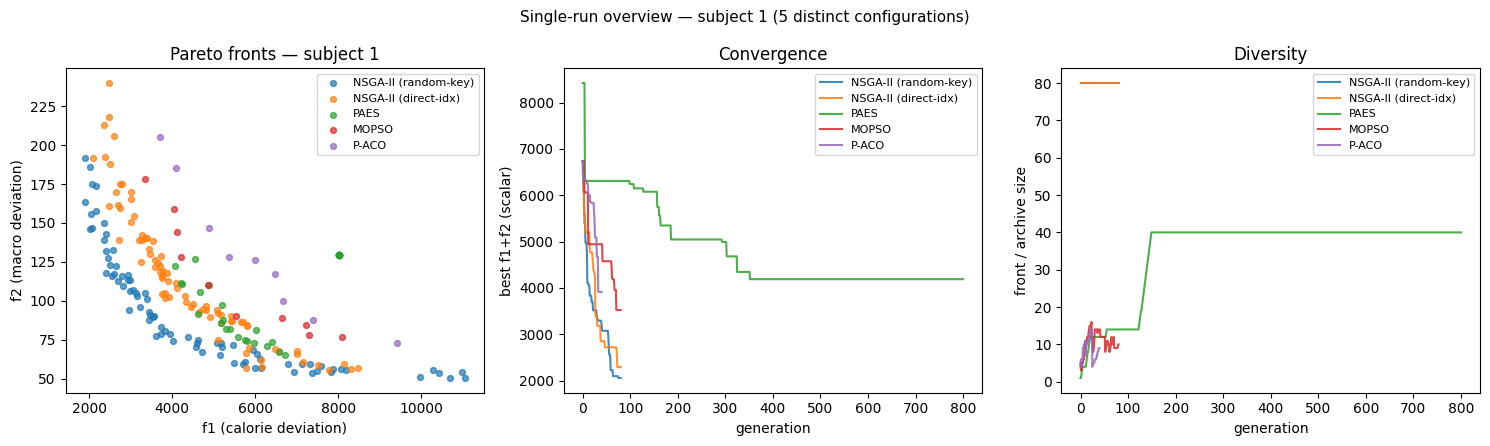

Saved: demo_overview.png


In [22]:
from diet_bao.experiment import AlgorithmConfig, load_real_dataset

# Load shared inputs if earlier cells were skipped.
if "foods" not in globals() or "subjects" not in globals():
    foods, subjects = load_real_dataset()

if "best" not in globals():
    best = pd.read_csv(TUNING_BEST_CSV)

PLOT_EXCLUDE = {"nsga2_di_penalty", "nsga2_di_death"}
PLOT_ORDER = [
    "nsga2_rk_repair",
    "nsga2_di_repair",
    "paes_di_repair",
    "mopso_rk",
    "paco_di",
]
LABEL_MAP = {
    "nsga2_rk_repair": "NSGA-II (random-key)",
    "nsga2_di_repair": "NSGA-II (direct-idx)",
    "paes_di_repair":  "PAES",
    "mopso_rk":        "MOPSO",
    "paco_di":         "P-ACO",
}

DEFAULT_HP = {
    "NSGA-II": {"pop_size": 80, "max_generations": 80, "mutation_rate": 0.1},
    "PAES": {"pop_size": 1, "max_generations": 800, "mutation_rate": 0.1, "max_archive_size": 80},
    "MOPSO": {"pop_size": 60, "max_generations": 80, "max_archive_size": 80, "inertia": 0.4, "c1": 1.5, "c2": 1.5, "leader_method": "sigma"},
    "P-ACO": {"pop_size": 40, "max_generations": 80, "max_archive_size": 80, "evaporation_rate": 0.1, "alpha": 1.0, "initial_pheromone": 1.0},
}

def pick(algo: str, defaults: dict | None = None) -> dict:
    out = dict(defaults or {})
    gdf = best[best["algorithm"] == algo]
    if gdf.empty:
        return out
    g = gdf.iloc[0]
    keys = [
        "pop_size",
        "max_generations",
        "mutation_rate",
        "inertia",
        "c1",
        "c2",
        "max_archive_size",
        "evaporation_rate",
        "alpha",
        "q",
        "initial_pheromone",
        "leader_method",
    ]
    out.update({k: g[k] for k in keys if k in g and pd.notna(g[k])})
    return out

def split(hp: dict, extras: list[str], pop_default: int = 50, gen_default: int = 50) -> dict:
    hp = dict(hp)
    pop = int(hp.pop("pop_size", pop_default))
    gens = int(hp.pop("max_generations", gen_default))
    extra = {k: hp[k] for k in extras if k in hp and pd.notna(hp[k])}
    return {"pop_size": pop, "max_generations": gens, "extra": extra}

nsga2 = split(pick("NSGA-II", DEFAULT_HP["NSGA-II"]), extras=["mutation_rate"])
paes = split(pick("PAES", DEFAULT_HP["PAES"]), extras=["mutation_rate", "max_archive_size"])
mopso = split(pick("MOPSO", DEFAULT_HP["MOPSO"]), extras=["max_archive_size", "inertia", "c1", "c2", "leader_method"])
paco = split(pick("P-ACO", DEFAULT_HP["P-ACO"]), extras=["max_archive_size", "evaporation_rate", "alpha", "q", "initial_pheromone"])

configs = [
    AlgorithmConfig("nsga2_di_repair", "NSGA-II", "direct_index", "repair", pop_size=nsga2["pop_size"], max_generations=nsga2["max_generations"], extra=nsga2["extra"]),
    AlgorithmConfig("nsga2_rk_repair", "NSGA-II", "random_key", "repair", pop_size=nsga2["pop_size"], max_generations=nsga2["max_generations"], extra=nsga2["extra"]),
    AlgorithmConfig("paes_di_repair", "PAES", "direct_index", "repair", pop_size=paes["pop_size"], max_generations=paes["max_generations"], extra=paes["extra"]),
    AlgorithmConfig("mopso_rk", "MOPSO", "random_key", "none", pop_size=mopso["pop_size"], max_generations=mopso["max_generations"], extra=mopso["extra"]),
    AlgorithmConfig("paco_di", "P-ACO", "direct_index", "none", pop_size=paco["pop_size"], max_generations=paco["max_generations"], extra=paco["extra"]),
]

benchmark_subjects = subjects
subj1 = next(s for s in benchmark_subjects if s.sujeto_id == 1)

demo_results = {}
for cfg in configs:
    if cfg.config_id in PLOT_EXCLUDE:
        continue
    runner = cfg.runner()
    kwargs = cfg.kwargs()
    res = runner(foods, subj1.edad, subj1.calorias, seed=100, **kwargs)
    demo_results[cfg.config_id] = res

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Pareto fronts ---
for cid in PLOT_ORDER:
    if cid not in demo_results:
        continue
    front = np.array(demo_results[cid]['front'])
    if len(front):
        axes[0].scatter(front[:, 0], front[:, 1], label=LABEL_MAP[cid], s=18, alpha=0.7)
axes[0].set_xlabel('f1 (calorie deviation)')
axes[0].set_ylabel('f2 (macro deviation)')
axes[0].set_title('Pareto fronts — subject 1')
axes[0].legend(fontsize=8)

# --- Convergence ---
for cid in PLOT_ORDER:
    if cid not in demo_results:
        continue
    trace = demo_results[cid].get('trace', {})
    g = trace.get('generation') or []
    v = trace.get('best_scalar') or []
    if g and v and len(g) == len(v):
        axes[1].plot(g, v, label=LABEL_MAP[cid], alpha=0.85)
axes[1].set_xlabel('generation')
axes[1].set_ylabel('best f1+f2 (scalar)')
axes[1].set_title('Convergence')
axes[1].legend(fontsize=8)

# --- Diversity (front / archive size) ---
for cid in PLOT_ORDER:
    if cid not in demo_results:
        continue
    trace = demo_results[cid].get('trace', {})
    g = trace.get('generation') or []
    fs = trace.get('front_size') or trace.get('archive_size') or []
    if g and fs and len(g) == len(fs):
        axes[2].plot(g, fs, label=LABEL_MAP[cid], alpha=0.85)
axes[2].set_xlabel('generation')
axes[2].set_ylabel('front / archive size')
axes[2].set_title('Diversity')
axes[2].legend(fontsize=8)

fig.suptitle('Single-run overview — subject 1 (5 distinct configurations)', fontsize=11)
fig.tight_layout()
fig.savefig(EXP_DIR / 'demo_overview.png', dpi=150)
plt.show()
print('Saved: demo_overview.png')

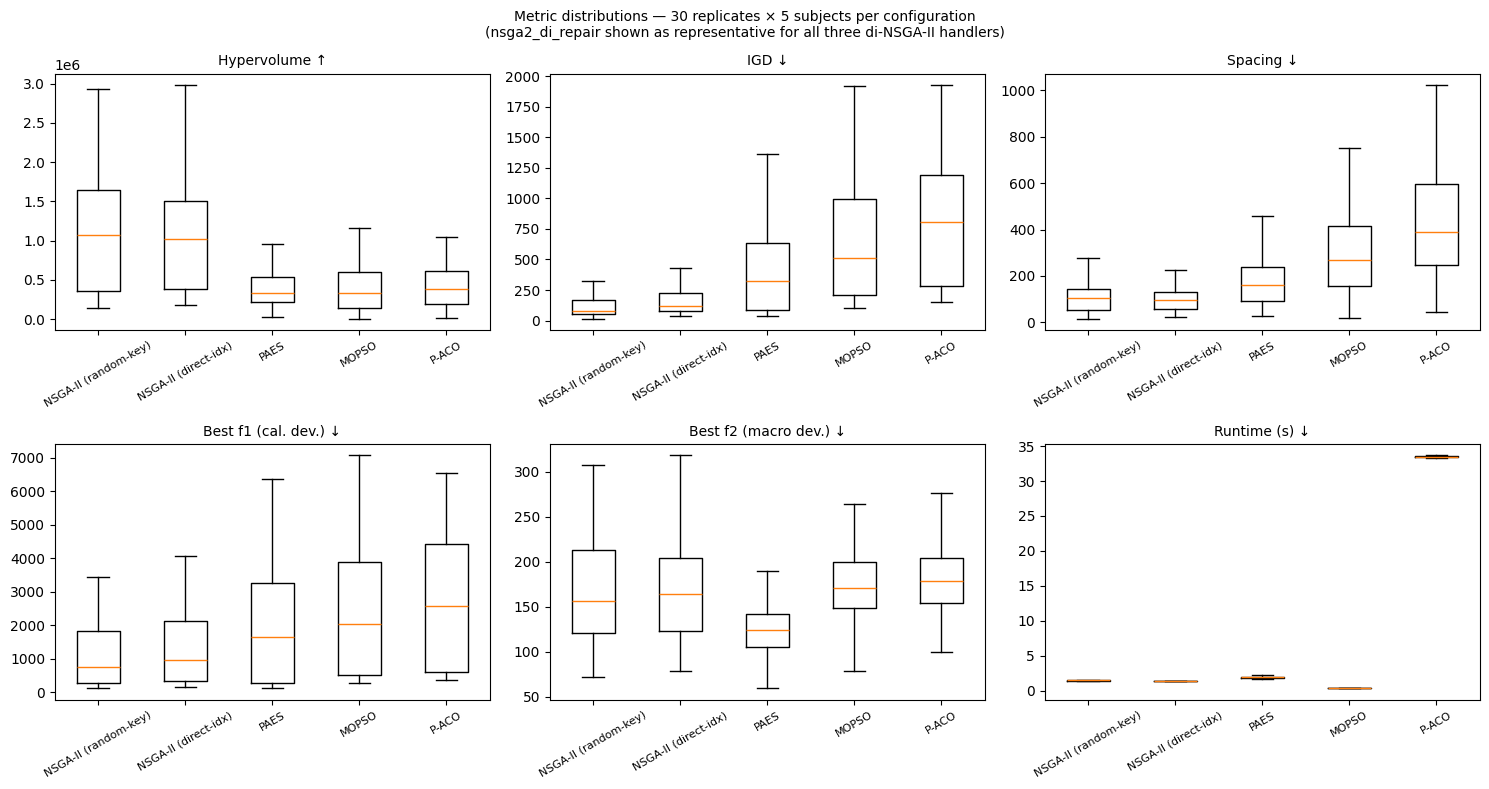

Saved: boxplots.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics = [
    ('hypervolume', 'Hypervolume ↑'),
    ('igd',         'IGD ↓'),
    ('spacing',     'Spacing ↓'),
    ('f1_best',     'Best f1 (cal. dev.) ↓'),
    ('f2_best',     'Best f2 (macro dev.) ↓'),
    ('runtime_s',   'Runtime (s) ↓'),
]

tick_labels = [LABEL_MAP[c] for c in PLOT_ORDER]

for ax, (col, title) in zip(axes.flat, metrics):
    data = [plot_runs[plot_runs.config_id == c][col].dropna().values for c in PLOT_ORDER]
    ax.boxplot(data, tick_labels=tick_labels, showfliers=False)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.set_title(title, fontsize=10)

fig.suptitle(
    'Metric distributions — 30 replicates × 5 subjects per configuration\n'
    '(nsga2_di_repair shown as representative for all three di-NSGA-II handlers)',
    fontsize=10,
)
fig.tight_layout()
fig.savefig(EXP_DIR / 'boxplots.png', dpi=150)
plt.show()
print('Saved: boxplots.png')

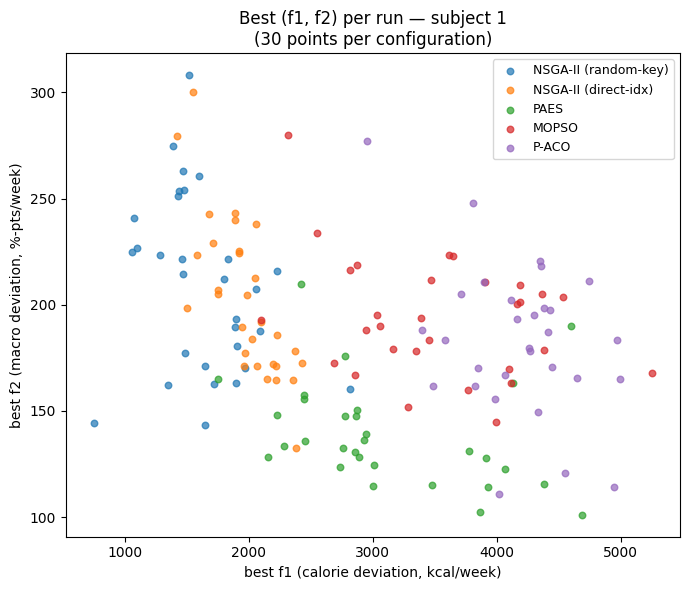

Saved: best_pts_subject_1.png


In [24]:
sub1 = plot_runs[plot_runs.subject_id == 1]

fig, ax = plt.subplots(figsize=(7, 6))
for cid in PLOT_ORDER:
    g = sub1[sub1.config_id == cid]
    if g.empty:
        continue
    ax.scatter(g['f1_best'], g['f2_best'], label=LABEL_MAP[cid], s=22, alpha=0.7)

ax.set_xlabel('best f1 (calorie deviation, kcal/week)')
ax.set_ylabel('best f2 (macro deviation, %-pts/week)')
ax.set_title('Best (f1, f2) per run — subject 1\n(30 points per configuration)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(EXP_DIR / 'best_pts_subject_1.png', dpi=150)
plt.show()
print('Saved: best_pts_subject_1.png')

## 6. Sanity checks

Lightweight assertions to catch the most common failure modes:
- Missing or incomplete runs (row counts)
- Mismatched configuration IDs between the plan and the results
- NaNs in the core metrics (HV/IGD/runtime/best objectives)

If these checks pass, the CSVs/figures are typically consistent with what the report expects.

In [25]:
expected = len(plan.configs) * len(benchmark_subjects) * plan.n_runs
assert len(runs) == expected, f'Unexpected row count: {len(runs)} != {expected}'
assert sorted(runs.config_id.unique()) == sorted([c.config_id for c in plan.configs])
assert runs[['hypervolume','igd','runtime_s','f1_best','f2_best']].notna().all().all()
print('All sanity checks passed.')


All sanity checks passed.
